# Telco Customer Churn — Data Exploration

---

## 0. Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
print('Setup complete')

Setup complete


---
## 1. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(5)


Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


---
## 2. Dataset Dictionary — What Each Column Means

| # | Column | Type | Description | ML Relevance |
|---|--------|------|-------------|--------------|
| 1 | `customerID` | ID | Unique customer identifier | **Drop** — no predictive value |
| 2 | `gender` | Binary | Male / Female | Low — usually weak predictor |
| 3 | `SeniorCitizen` | Binary (0/1) | Whether the customer is 65+ | Medium — seniors churn differently |
| 4 | `Partner` | Binary | Has a spouse/partner (Yes/No) | Medium — tied to household stability |
| 5 | `Dependents` | Binary | Has dependents (Yes/No) | Medium — families tend to stay |
| 6 | `tenure` | Numeric | Months with the company | **High** — key loyalty indicator |
| 7 | `PhoneService` | Binary | Has phone service (Yes/No) | Low — nearly all customers have it |
| 8 | `MultipleLines` | Categorical | No / Yes / No phone service | Medium |
| 9 | `InternetService` | Categorical | DSL / Fiber optic / No | **High** — Fiber users churn more |
| 10 | `OnlineSecurity` | Categorical | No / Yes / No internet service | High — no-security → higher churn |
| 11 | `OnlineBackup` | Categorical | No / Yes / No internet service | Medium |
| 12 | `DeviceProtection` | Categorical | No / Yes / No internet service | Medium |
| 13 | `TechSupport` | Categorical | No / Yes / No internet service | High |
| 14 | `StreamingTV` | Categorical | No / Yes / No internet service | Medium |
| 15 | `StreamingMovies` | Categorical | No / Yes / No internet service | Medium |
| 16 | `Contract` | Categorical | Month-to-month / One year / Two year | **Very High** — strongest single predictor |
| 17 | `PaperlessBilling` | Binary | Enrolled in paperless billing (Yes/No) | Medium |
| 18 | `PaymentMethod` | Categorical | 4 methods (Electronic check, etc.) | High |
| 19 | `MonthlyCharges` | Numeric | Current monthly bill (USD) | **High** |
| 20 | `TotalCharges` | Numeric (stored as string) | Cumulative charges — **has whitespace NAs** | High — correlated with tenure |
| 21 | `Churn` | **Target** | Yes / No — churned in last month | **TARGET** |

---
## 3. Schema & Data Types

In [5]:
schema = pd.DataFrame({
    'dtype'       : df.dtypes,
    'non_null'    : df.notnull().sum(),
    'null_count'  : df.isnull().sum(),
    'null_%'      : (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique'    : df.nunique(),
    'sample'      : df.iloc[0]
})
display(schema)

,dtype,non_null,null_count,null_%,n_unique,sample
customerID,str,7043,0,0.0000,7043,7590-VHVEG
gender,str,7043,0,0.0000,2,Female
SeniorCitizen,int64,7043,0,0.0000,2,0
Partner,str,7043,0,0.0000,2,Yes
Dependents,str,7043,0,0.0000,2,No
tenure,int64,7043,0,0.0000,73,1
PhoneService,str,7043,0,0.0000,2,No
MultipleLines,str,7043,0,0.0000,3,No phone service
InternetService,str,7043,0,0.0000,3,DSL
OnlineSecurity,str,7043,0,0.0000,3,No


In [6]:
# TotalCharges is read as object — coerce to numeric and expose hidden NAs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges NAs after coercion: {df['TotalCharges'].isna().sum()}")
# These are new customers (tenure == 0) who haven't been billed yet
display(df[df['TotalCharges'].isna()][['customerID','tenure','MonthlyCharges','TotalCharges','Churn']])

TotalCharges NAs after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.5500,NaN,No
753,3115-CZMZD,0,20.2500,NaN,No
936,5709-LVOEQ,0,80.8500,NaN,No
1082,4367-NUYAO,0,25.7500,NaN,No
1340,1371-DWPAZ,0,56.0500,NaN,No
3331,7644-OMVMY,0,19.8500,NaN,No
3826,3213-VVOLG,0,25.3500,NaN,No
4380,2520-SGTTA,0,20.0000,NaN,No
5218,2923-ARZLG,0,19.7000,NaN,No
6670,4075-WKNIU,0,73.3500,NaN,No


---
## 4. Target Variable — Churn Distribution

/tmp/ipykernel_72625/2136278151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette=['#2ecc71','#e74c3c'])


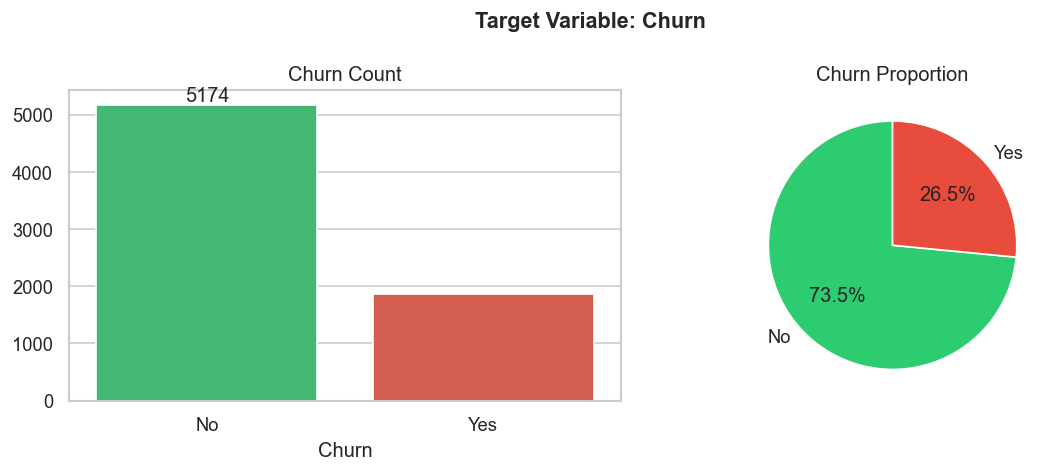

Class imbalance ratio  No:Yes = 2.8:1
Churn rate: 26.5%  →  dataset is IMBALANCED — handle in modeling step


In [7]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count bar
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette=['#2ecc71','#e74c3c'])
axes[0].set_title('Churn Count')
axes[0].bar_label(axes[0].containers[0], fmt='%d')

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Class imbalance ratio  No:Yes = {churn_counts['No']/churn_counts['Yes']:.1f}:1")
print(f"Churn rate: {churn_pct['Yes']:.1f}%  →  dataset is IMBALANCED — handle in modeling step")

---
## 5. Numerical Features — Distributions & Outliers

/tmp/ipykernel_72625/1303036351.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],
/tmp/ipykernel_72625/1303036351.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],
/tmp/ipykernel_72625/1303036351.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],


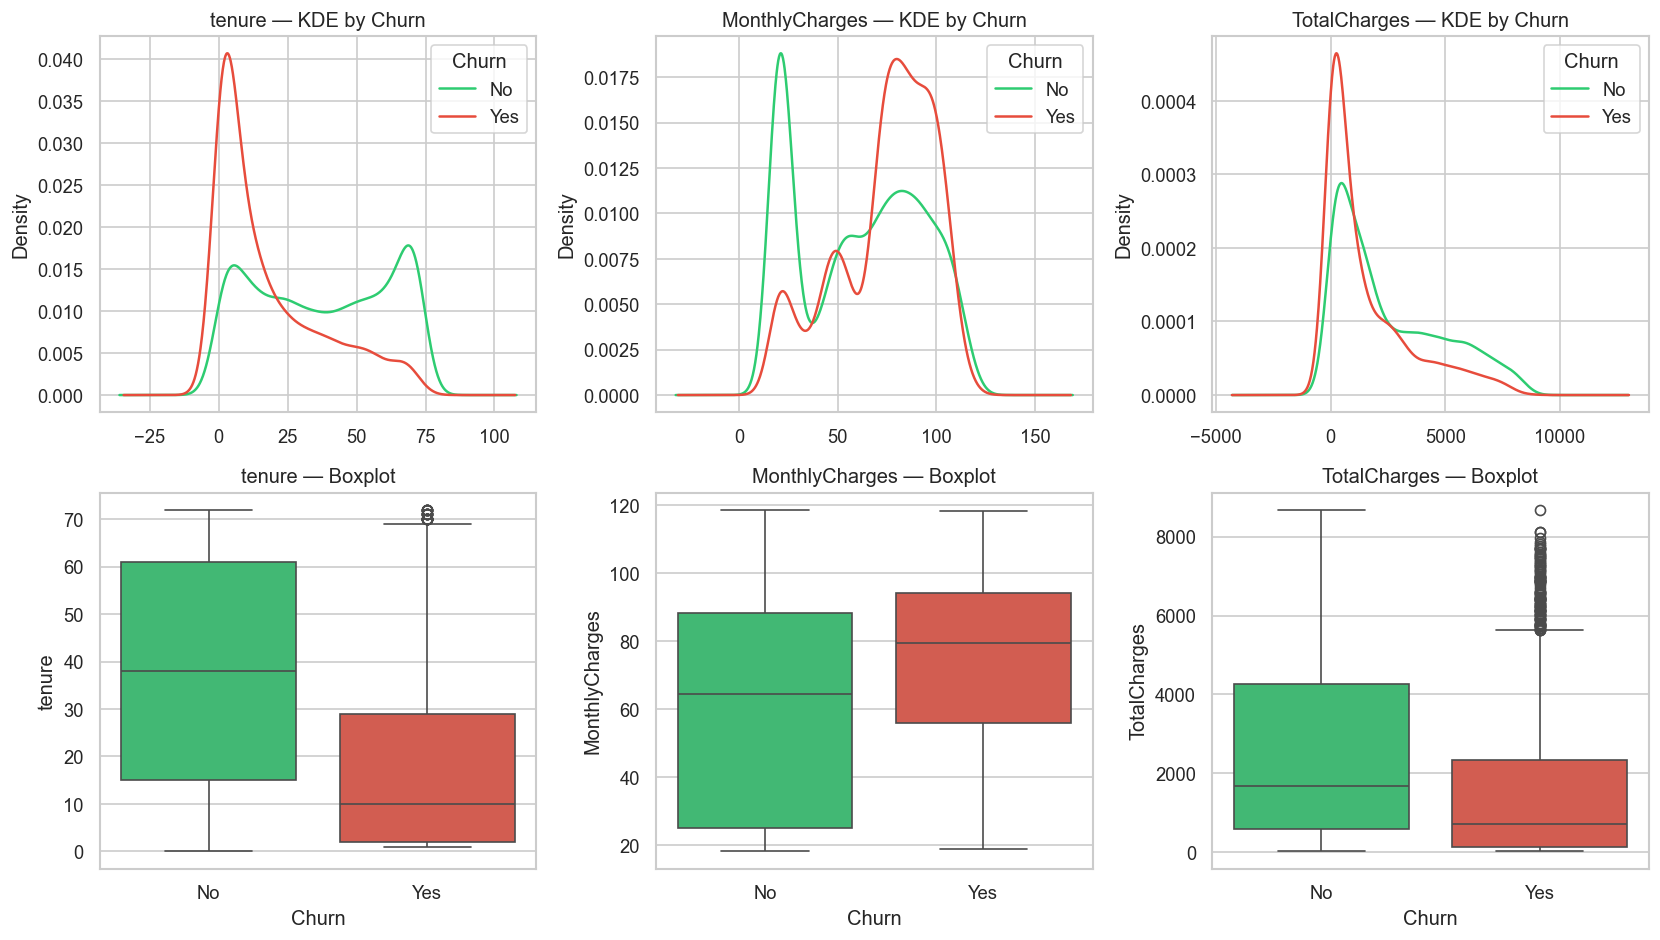

,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3711,64.7617,2283.3004
std,24.5595,30.0900,2266.7714
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4750
75%,55.0000,89.8500,3794.7375
max,72.0000,118.7500,8684.8000


In [8]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # KDE by churn
    for label, color in [('No','#2ecc71'),('Yes','#e74c3c')]:
        subset = df[df['Churn'] == label][col].dropna()
        subset.plot.kde(ax=axes[0, i], label=label, color=color)
    axes[0, i].set_title(f'{col} — KDE by Churn')
    axes[0, i].legend(title='Churn')

    # Boxplot
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i],
                palette={'No':'#2ecc71','Yes':'#e74c3c'})
    axes[1, i].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png', bbox_inches='tight')
plt.show()

display(df[num_cols].describe())

### Key observations — Numerical
- **tenure**: Churners cluster in the first 1–12 months. Long-tenure customers rarely churn.
- **MonthlyCharges**: Churners pay significantly more (~$74 vs ~$61). Fiber optic drives this.
- **TotalCharges**: Low for churners (new customers). Highly correlated with tenure × MonthlyCharges.

---
## 6. Categorical Features — Churn Rate per Category

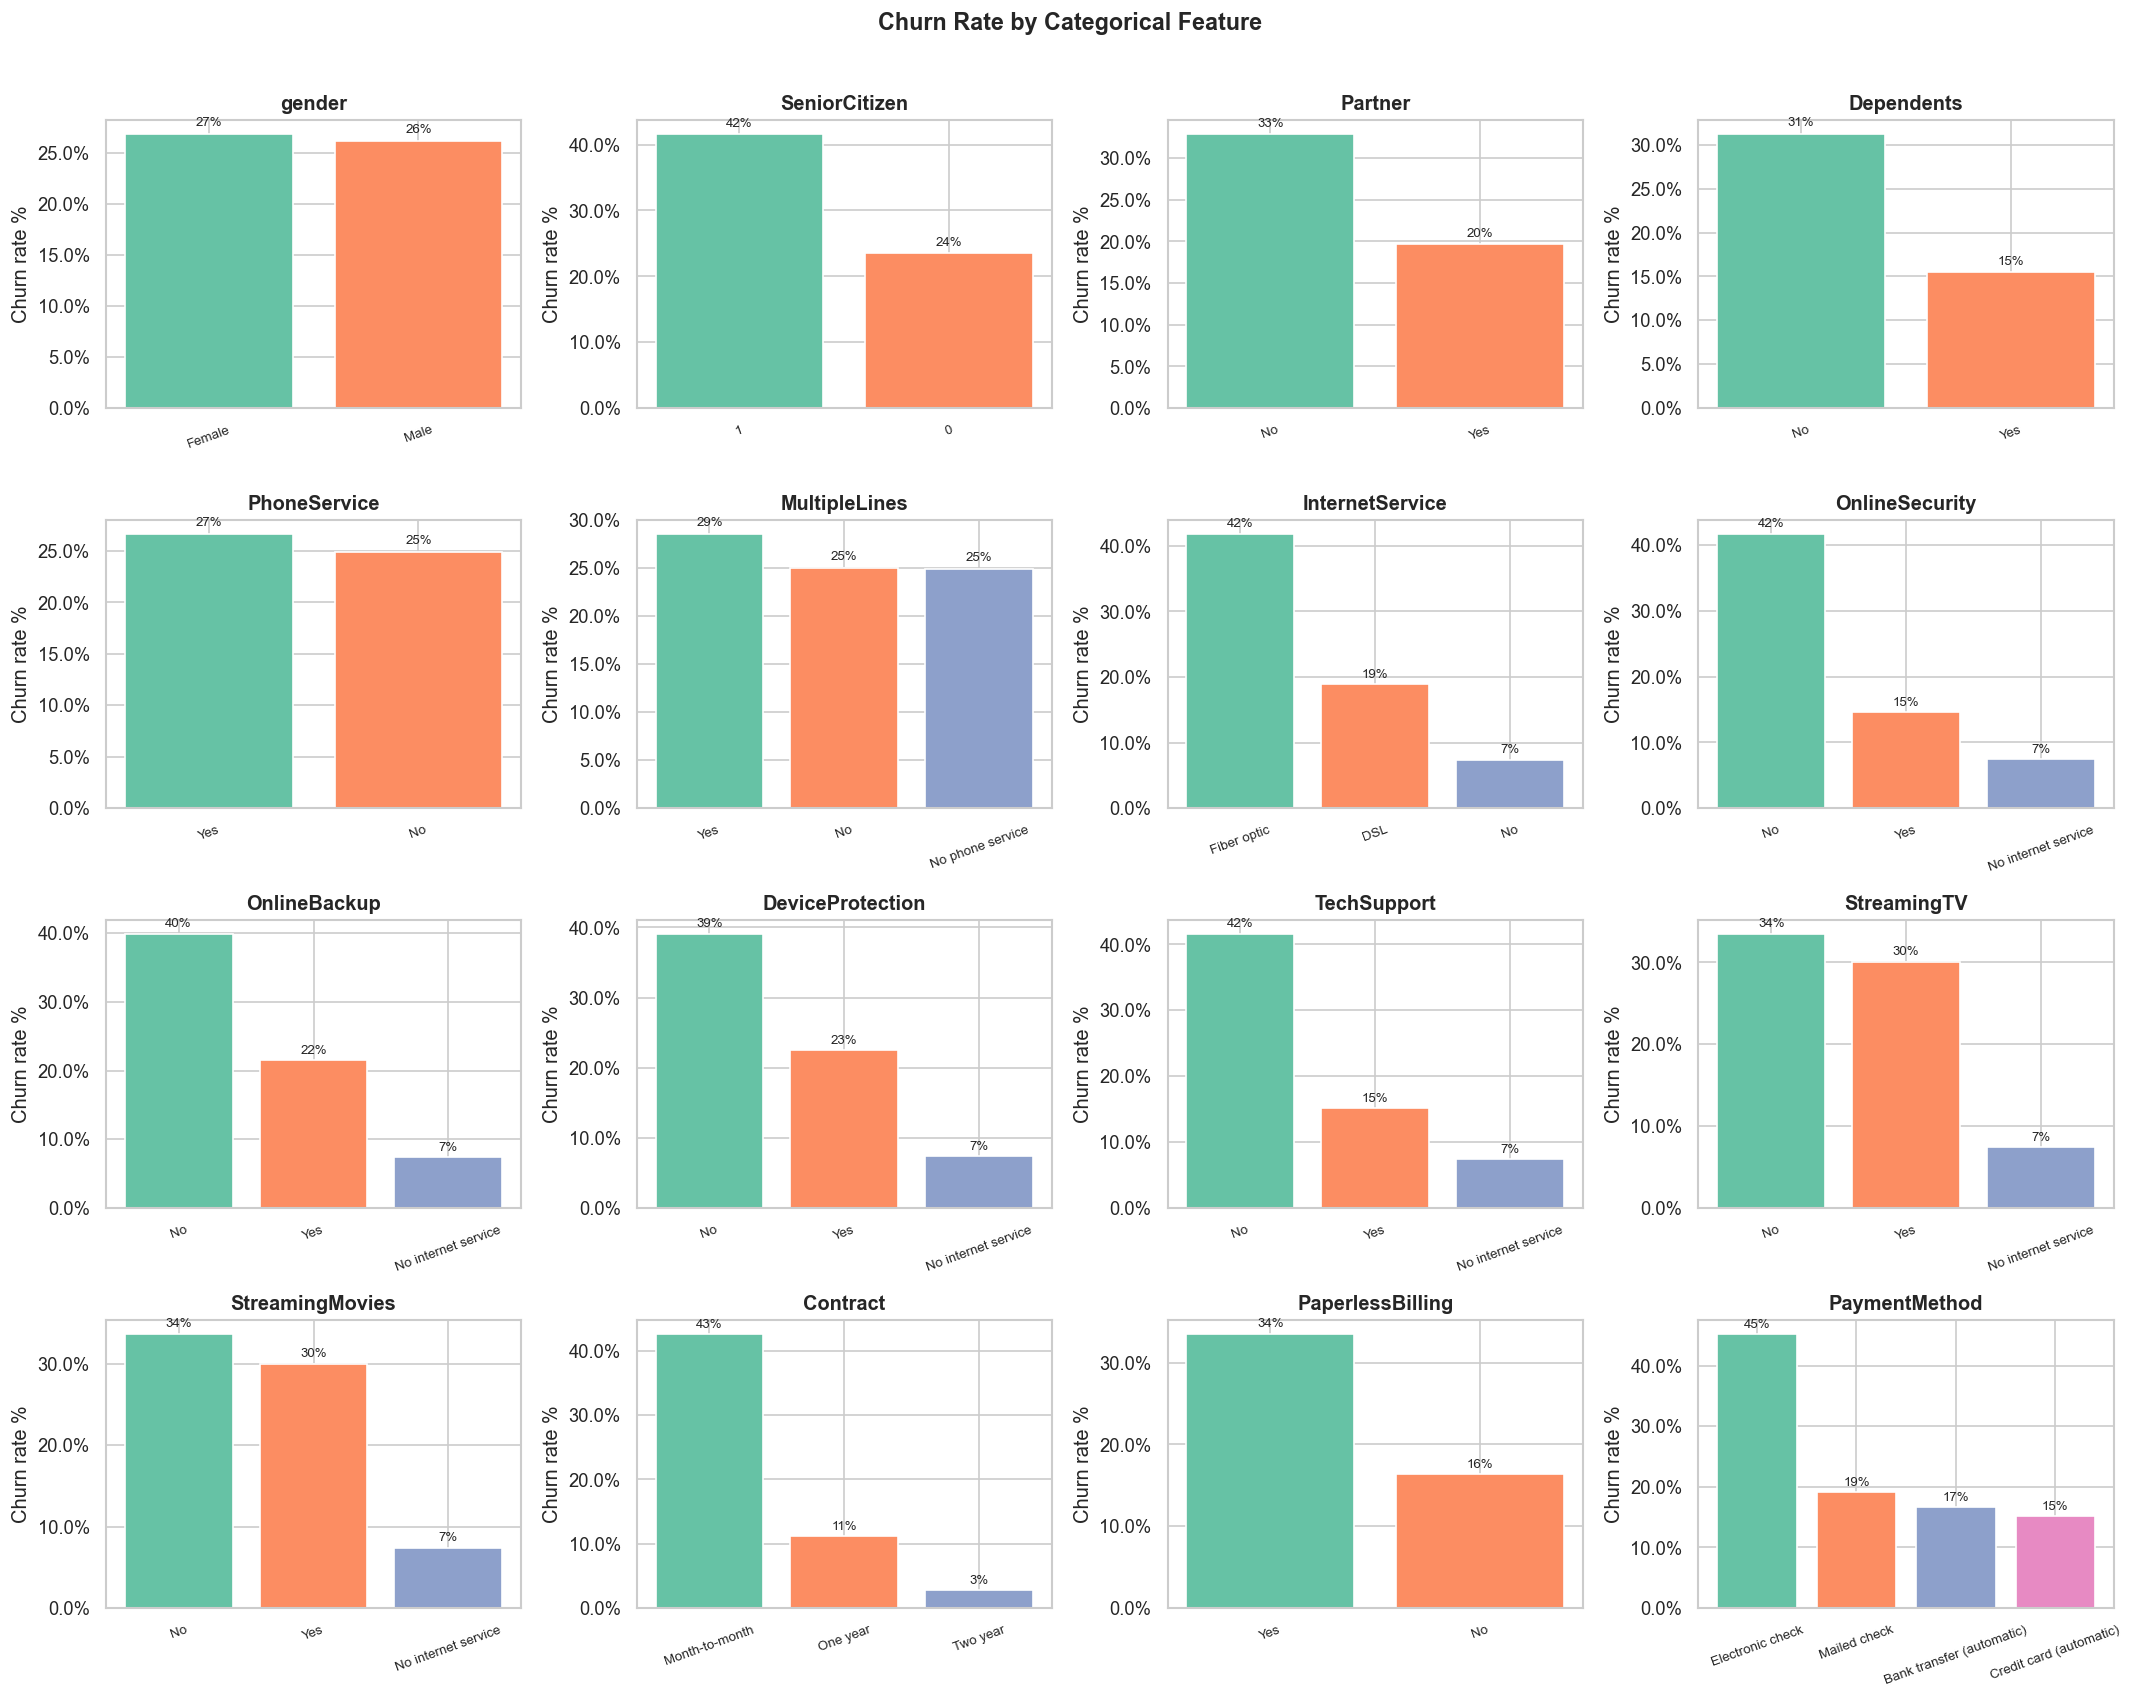

In [9]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
            'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaperlessBilling','PaymentMethod']

# Convert target to binary for aggregation
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

n = len(cat_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    bars = axes[idx].bar(churn_rate.index.astype(str), churn_rate.values * 100,
                          color=sns.color_palette('Set2', len(churn_rate)))
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Churn rate %')
    axes[idx].tick_params(axis='x', rotation=20, labelsize=8)
    axes[idx].yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar in bars:
        h = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                       f'{h:.0f}%', ha='center', va='bottom', fontsize=8)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/categorical_churn_rates.png', bbox_inches='tight')
plt.show()

---
## 7. Correlation Heatmap (Numerical + Encoded Target)

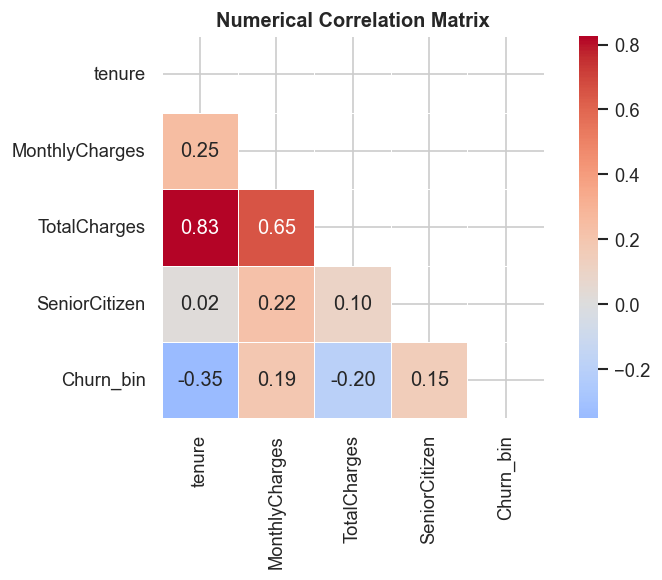

In [10]:
num_for_corr = df[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn_bin']].copy()

fig, ax = plt.subplots(figsize=(7, 5))
corr = num_for_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Numerical Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 8. Key Findings Summary

| Finding | Impact on Preprocessing |
|---------|-------------------------|
| **Class imbalance** — 73.5% No / 26.5% Yes | Use SMOTE or class_weight='balanced' |
| **TotalCharges** — 11 hidden NAs (whitespace) | Coerce to float; impute or drop |
| **TotalCharges ≈ tenure × MonthlyCharges** (ρ=0.83) | Consider dropping or creating ratio feature |
| **Contract** — Month-to-month → 43% churn rate | Strong categorical feature, keep |
| **InternetService=Fiber** → ~42% churn | Key segment feature |
| **OnlineSecurity/TechSupport=No** → high churn | Service add-on bundle matters |
| **tenure** — strong negative correlation with churn (ρ=-0.35) | Engineer tenure bins (new/mid/loyal) |
| **customerID** — identifier, no signal | Drop before modeling |

---
## 9. Export Clean Schema

In [11]:
df.drop(columns=['Churn_bin'], inplace=True)
df.to_csv('../data/telco_churn_loaded.csv', index=False)
print('Saved to data/telco_churn_loaded.csv')
print(f'Final shape: {df.shape}')

Saved to data/telco_churn_loaded.csv
Final shape: (7043, 21)
